## MSFT Bull Call Spread

INPUTS (the only things you provide):

`` Ticker ``     : MSFT

`` K1 (long) ``  : 440

`` K2 (short) `` : 520

`` Expiry ``     : 2026-09-18

EVERYTHING ELSE is computed:
- `` S0  (spot) ``         → last close from yfinance

- ``sigma (volatility)``   → realized vol from log-returns (last 252 trading days)

- `` r (risk-free) ``      → most recent DTB6 (6-month T-bill) from local CSV

- `` Premiums ``           → CRR American binomial pricer

- `` Net premium paid ``   → premium_long − premium_short

- `` GREEKS ``             → delta, gamma, vega, theta, rho (finite differences on CRR tree) computed for each leg AND for the full spread

#### 1. Librerías y dependencias

In [21]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from datetime import date, timedelta
import yfinance as yf

#### 2. User inputs

In [22]:
TICKER  = "MSFT"
K_long  = 440.0
K_short = 540.0 #originla 520
EXPIRY  = date(2026, 9, 18)

### 3. Funciones

#### 3.1. Cox-Ross-Rubinstein - American binomial pricer

In [23]:
def crr_american(S, K, T, r, sigma, N=500, option_type="C"):
    if T <= 0:
        return max(S - K, 0.0) if option_type == "C" else max(K - S, 0.0)

    dt   = T / N
    u    = math.exp(sigma * math.sqrt(dt))
    d    = 1.0 / u
    disc = math.exp(-r * dt)
    pu   = (math.exp(r * dt) - d) / (u - d)
    pd   = 1.0 - pu

    St = np.array([S * (u ** (N - 2 * j)) for j in range(N + 1)])
    V  = np.maximum(St - K, 0.0) if option_type == "C" else np.maximum(K - St, 0.0)

    for i in range(N - 1, -1, -1):
        St_i   = np.array([S * (u ** (i - 2 * j)) for j in range(i + 1)])
        V_hold = disc * (pu * V[:-1] + pd * V[1:])
        V_intr = (np.maximum(St_i - K, 0.0) if option_type == "C"
                  else np.maximum(K - St_i, 0.0))
        V = np.maximum(V_hold, V_intr)

    return float(V[0])

#### 3.2. Griegas (Greeks)

In [24]:
def greeks_american(S, K, T, r, sigma, N=500, option_type="C"):
    """
    Return a dict with delta, gamma, vega, theta, rho for an American
    option priced on the CRR tree using central finite differences.

    Conventions (industry standard, easier to read):
        delta  : per $1 change in spot           (dimensionless)
        gamma  : per $1 change in spot           (1/$)
        vega   : per 1 percentage point of vol   (so divided by 100)
        theta  : per 1 calendar day              (so divided by 365)
        rho    : per 1 percentage point of rate  (so divided by 100)

    NOTE on the bumps:
      We use a SMALL bump (≈1% of spot) for Delta because that gives
      the most accurate first derivative, but a LARGER bump (≈3% of
      spot) for Gamma.  Reason: the CRR tree is piecewise-linear in
      the strike-relative spacing, so a too-small bump in S makes the
      second derivative oscillate as N changes (a well-known artifact).
      A 3% bump averages over enough nodes to give a stable Gamma that
      converges to the Black-Scholes value as N→∞.
    """
    # --- bumps ---
    dS_d  = max(S * 0.01, 0.01)        # 1% of spot for Delta
    dS_g  = max(S * 0.03, 0.03)        # 3% of spot for Gamma (more stable on CRR)
    dSig  = 0.01                       # 100 bp absolute bump in vol (we re-scale)
    dR    = 0.01                       # 100 bp absolute bump in rate (we re-scale)
    dT_yr = 1.0 / 365.0                # one calendar day forward (we re-scale)

    # base price (kept around for theta forward diff)
    P0 = crr_american(S, K, T, r, sigma, N, option_type)

    # ---- Delta (central diff in S, small bump for accuracy) ----
    P_up_d = crr_american(S + dS_d, K, T, r, sigma, N, option_type)
    P_dn_d = crr_american(S - dS_d, K, T, r, sigma, N, option_type)
    delta  = (P_up_d - P_dn_d) / (2.0 * dS_d)

    # ---- Gamma (central second diff in S, larger bump for stability) ----
    P_up_g = crr_american(S + dS_g, K, T, r, sigma, N, option_type)
    P_dn_g = crr_american(S - dS_g, K, T, r, sigma, N, option_type)
    gamma  = (P_up_g - 2.0 * P0 + P_dn_g) / (dS_g ** 2)

    # ---- Vega (central diff in sigma; quoted per 1% vol move) ----
    P_vu   = crr_american(S, K, T, r, sigma + dSig, N, option_type)
    P_vd   = crr_american(S, K, T, r, max(sigma - dSig, 1e-6), N, option_type)
    vega   = (P_vu - P_vd) / (2.0 * dSig) / 100.0   # → per 1% (per 0.01) move

    # ---- Rho (central diff in r; quoted per 1% rate move) ----
    P_ru   = crr_american(S, K, T, r + dR, sigma, N, option_type)
    P_rd   = crr_american(S, K, T, r - dR, sigma, N, option_type)
    rho    = (P_ru - P_rd) / (2.0 * dR) / 100.0     # → per 1% (per 0.01) move

    # ---- Theta (forward diff in T; quoted per 1 calendar day) ----
    if T - dT_yr > 0:
        P_t1 = crr_american(S, K, T - dT_yr, r, sigma, N, option_type)
        theta = (P_t1 - P0) / dT_yr / 365.0          # → per 1 calendar day
    else:
        theta = float('nan')

    return {"price": P0, "delta": delta, "gamma": gamma,
            "vega": vega, "theta": theta, "rho": rho}

#### 3.3. Extraer precios historicos de yahoo finance

In [25]:
print(f"📥 Fetching {TICKER} historical prices from yfinance...")
hist = yf.download(TICKER, period="2y", end="2026-04-24", progress=False, auto_adjust=True)
if hist.empty:
    raise RuntimeError("Could not fetch price data.")

# Spot price = last close
S0 = float(hist["Close"].iloc[-1].item())
last_date = hist.index[-1].date()
print(f"   Last close on {last_date}: ${S0:.2f}")

# Realized volatility (annualized) from last ~252 trading days of log returns
log_ret = np.log(hist["Close"] / hist["Close"].shift(1)).dropna()
window = min(252, len(log_ret))
sigma_realized = float(log_ret.tail(window).std().item() * math.sqrt(252))
print(f"   Realized volatility ({window}d, annualized): {sigma_realized*100:.2f}%")

# Risk-free rate from local DTB6.csv (6-month T-bill, matches ~6-month strategy duration)
print("📥 Loading risk-free rate from DTB6.csv...")
dtb6 = pd.read_csv("DTB6.csv")
dtb6["DTB6"] = pd.to_numeric(dtb6["DTB6"], errors="coerce")
r_pct = float(dtb6["DTB6"].dropna().iloc[-1])
r = r_pct / 100.0
print(f"   Most recent DTB6: {r_pct:.2f}% → r = {r:.4f}")

📥 Fetching MSFT historical prices from yfinance...
   Last close on 2026-04-23: $415.75
   Realized volatility (252d, annualized): 24.81%
📥 Loading risk-free rate from DTB6.csv...
   Most recent DTB6: 3.60% → r = 0.0360


### 4. Establecer variables para inputs de los derivados

In [26]:
sigma_long  = sigma_realized
sigma_short = sigma_realized

In [27]:
last_date

datetime.date(2026, 4, 23)

### 5. Pricear las "legs"

In [28]:
T_total    = (EXPIRY - last_date).days / 365.0
prem_long  = crr_american(S0, K_long,  T_total, r, sigma_long,  500, "C")
prem_short = crr_american(S0, K_short, T_total, r, sigma_short, 500, "C")
net_premium = prem_long - prem_short

print()
print("─" * 60)
print("STRATEGY PARAMETERS (all derived):")
print("─" * 60)
print(f"  Spot price S0           : ${S0:.2f}")
print(f"  Volatility (realized)   : {sigma_realized*100:.2f}%")
print(f"  Risk-free rate r        : {r*100:.2f}%")
print(f"  Days to expiry          : {(EXPIRY - last_date).days}")
print()
print(f"  Long  Call K={K_long}   : premium = ${prem_long:.2f}")
print(f"  Short Call K={K_short}  : premium = ${prem_short:.2f}")
print(f"  Net premium paid        : ${net_premium:.2f} per share")
print(f"  Cost per contract (×100): ${net_premium*100:.2f}")
print("─" * 60)


────────────────────────────────────────────────────────────
STRATEGY PARAMETERS (all derived):
────────────────────────────────────────────────────────────
  Spot price S0           : $415.75
  Volatility (realized)   : 24.81%
  Risk-free rate r        : 3.60%
  Days to expiry          : 148

  Long  Call K=440.0   : premium = $18.73
  Short Call K=540.0  : premium = $1.88
  Net premium paid        : $16.85 per share
  Cost per contract (×100): $1685.24
────────────────────────────────────────────────────────────


### 6. Griegas 

Individuales y de la estrategia completa

In [29]:
# Use a slightly larger N for greeks to reduce CRR oscillation noise
# in the second derivative (gamma).  N=800 is a good compromise
# between stability and runtime for this maturity.
N_GREEKS = 800

print("\n⚙️  Computing greeks (CRR American, finite differences)...")
g_long  = greeks_american(S0, K_long,  T_total, r, sigma_long,  N_GREEKS, "C")
g_short = greeks_american(S0, K_short, T_total, r, sigma_short, N_GREEKS, "C")

# Spread = LONG K1 − SHORT K2.  Greeks are linear in the position, so
# the spread greeks are simply (long greek) − (short greek).
g_spread = {k: g_long[k] - g_short[k]
            for k in ("price", "delta", "gamma", "vega", "theta", "rho")}

# Pretty-print as a table
def fmt(x, w=10, dec=4):
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return f"{'n/a':>{w}}"
    return f"{x:>{w}.{dec}f}"

print("\n" + "═" * 78)
print("  GREEKS  (per 1 share — multiply by 100 for one standard contract)")
print("═" * 78)
header = f"  {'':<22}{'Price':>12}{'Delta':>11}{'Gamma':>11}{'Vega':>11}{'Theta':>11}{'Rho':>11}"
print(header)
print("  " + "─" * 76)
print(f"  {'Long Call  K=' + str(int(K_long)):<22}"
      f"{fmt(g_long['price'],12,4)}{fmt(g_long['delta'],11,4)}"
      f"{fmt(g_long['gamma'],11,4)}{fmt(g_long['vega'],11,4)}"
      f"{fmt(g_long['theta'],11,4)}{fmt(g_long['rho'],11,4)}")
print(f"  {'Short Call K=' + str(int(K_short)):<22}"
      f"{fmt(g_short['price'],12,4)}{fmt(g_short['delta'],11,4)}"
      f"{fmt(g_short['gamma'],11,4)}{fmt(g_short['vega'],11,4)}"
      f"{fmt(g_short['theta'],11,4)}{fmt(g_short['rho'],11,4)}")
print("  " + "─" * 76)
print(f"  {'Bull Call Spread':<22}"
      f"{fmt(g_spread['price'],12,4)}{fmt(g_spread['delta'],11,4)}"
      f"{fmt(g_spread['gamma'],11,4)}{fmt(g_spread['vega'],11,4)}"
      f"{fmt(g_spread['theta'],11,4)}{fmt(g_spread['rho'],11,4)}")
print("═" * 78)
print("  Units:  Delta=per $1     Gamma=per $1²     Vega=per 1% vol")
print("          Theta=per 1 day  Rho=per 1% rate")
print("═" * 78)

# Per-contract view (each contract = 100 shares)
multiplier = 100
print("\n  Per contract (×100 shares):")
print(f"    Spread Delta : {g_spread['delta']*multiplier:>10.2f}  $/$1 move")
print(f"    Spread Gamma : {g_spread['gamma']*multiplier:>10.4f}  $/$1²")
print(f"    Spread Vega  : {g_spread['vega']*multiplier:>10.2f}  $ per 1% vol")
print(f"    Spread Theta : {g_spread['theta']*multiplier:>10.2f}  $ per day")
print(f"    Spread Rho   : {g_spread['rho']*multiplier:>10.2f}  $ per 1% rate")
print("═" * 78)


⚙️  Computing greeks (CRR American, finite differences)...

══════════════════════════════════════════════════════════════════════════════
  GREEKS  (per 1 share — multiply by 100 for one standard contract)
══════════════════════════════════════════════════════════════════════════════
                               Price      Delta      Gamma       Vega      Theta        Rho
  ────────────────────────────────────────────────────────────────────────────
  Long Call  K=440           18.7423     0.4267     0.0061     1.0347    -0.1018     0.6415
  Short Call K=540            1.8813     0.0692     0.0020     0.3516    -0.0318     0.1086
  ────────────────────────────────────────────────────────────────────────────
  Bull Call Spread           16.8611     0.3574     0.0041     0.6831    -0.0700     0.5329
══════════════════════════════════════════════════════════════════════════════
  Units:  Delta=per $1     Gamma=per $1²     Vega=per 1% vol
          Theta=per 1 day  Rho=per 1% rate
════

### 7. THREE VALUATION DATES (today, mid-life, expiry)

In [30]:
mid_date = last_date + timedelta(days=(EXPIRY - last_date).days // 2)
val_dates   = [last_date, mid_date, EXPIRY]
LABELS_DATE = [d.strftime("%b %d, %Y") for d in val_dates]
COLORS      = ["#4f8ef7", "#3fc77a", "#f5c518"]

### 8. P&L

In [41]:
S_min, S_max = int(S0 * 0.75), int(S0 * 1.50)
S_grid = np.linspace(S_min, S_max, 300)

def compute_pnl(val_date):
    T_rem = max((EXPIRY - val_date).days / 365.0, 0.0)
    pnl = []
    for S in S_grid:
        if T_rem <= 0:
            vl = max(S - K_long,  0.0)
            vs = max(S - K_short, 0.0)
        else:
            vl = crr_american(S, K_long,  T_rem, r, sigma_long,  500, "C")
            vs = crr_american(S, K_short, T_rem, r, sigma_short, 500, "C")
        pnl.append(((vl - prem_long) - (vs - prem_short)) * multiplier)
    return np.array(pnl)

print("\n⚙️  Computing P&L curves...")
all_pnl = [compute_pnl(d) for d in val_dates]
print("   Done.")

def find_breakeven(S_grid, pnl):
    for i in range(len(pnl) - 1):
        if (pnl[i] <= 0 <= pnl[i+1]) or (pnl[i] >= 0 >= pnl[i+1]):
            x0, x1 = S_grid[i], S_grid[i+1]
            y0, y1 = pnl[i], pnl[i+1]
            return x0 - y0 * (x1 - x0) / (y1 - y0)
    return None


⚙️  Computing P&L curves...
   Done.


### 9. Gráfico

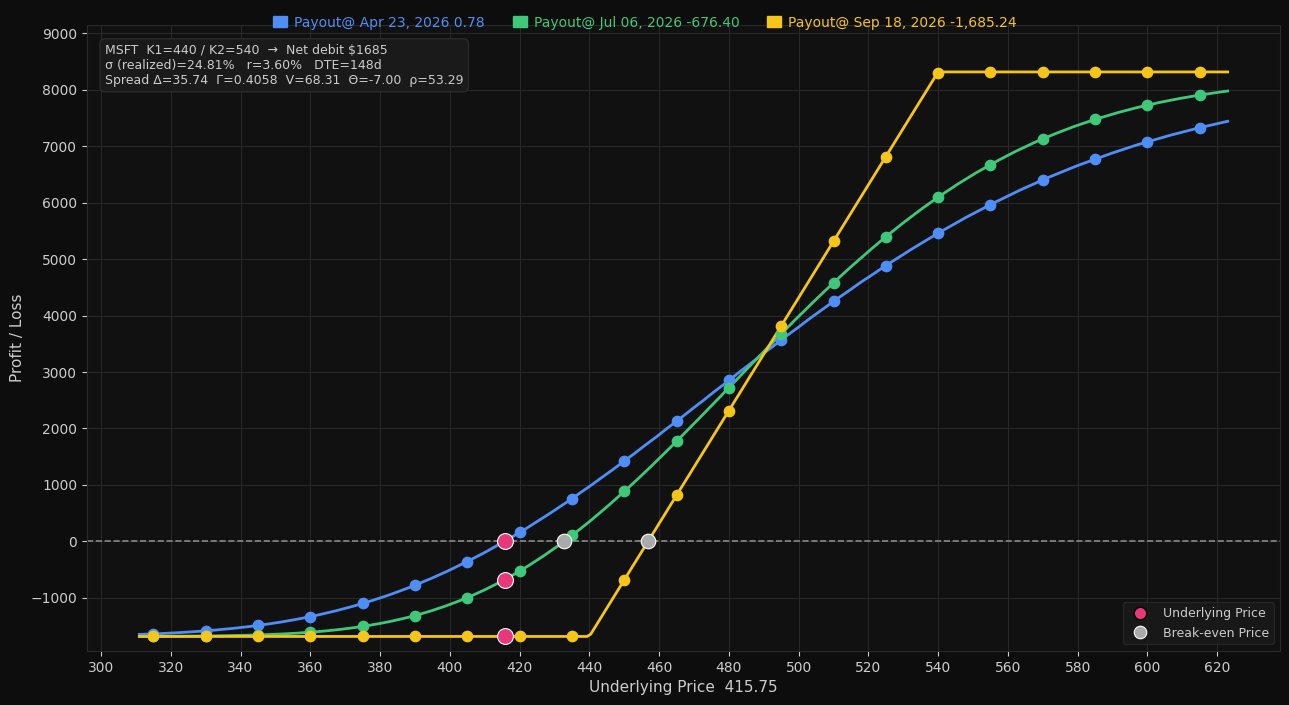

In [42]:
BG, PANEL_BG = "#0d0d0d", "#111111"
GRID_CLR, TEXT_CLR = "#2a2a2a", "#cccccc"

fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
ax.set_facecolor(PANEL_BG)
ax.axhline(0, color="#888888", linewidth=1.2, linestyle="--", zorder=2)

scatter_x = np.arange(int(S_min // 15) * 15 + 15, S_max, 15)

for pnl, color, ldate in zip(all_pnl, COLORS, LABELS_DATE):
    scatter_y = np.interp(scatter_x, S_grid, pnl)
    ax.plot(S_grid, pnl, color=color, linewidth=2.0, zorder=3)
    ax.scatter(scatter_x, scatter_y, color=color, s=55, zorder=4)

    pnl_now = float(np.interp(S0, S_grid, pnl))
    ax.scatter([S0], [pnl_now], color="#e8387a", s=130, zorder=7,
               edgecolors="#ffffff", linewidths=0.8)

    be = find_breakeven(S_grid, pnl)
    if be is not None:
        be_y = float(np.interp(be, S_grid, pnl))
        ax.scatter([be], [be_y], color="#aaaaaa", s=110, zorder=6,
                   edgecolors="#ffffff", linewidths=0.8)

ax.set_xlim(S_min - 15, S_max + 15)
y_lo = min(p.min() for p in all_pnl) * 1.15
y_hi = max(p.max() for p in all_pnl) * 1.10
ax.set_ylim(y_lo, y_hi)

ax.set_xlabel(f"Underlying Price  {S0:.2f}", color=TEXT_CLR, fontsize=11)
ax.set_ylabel("Profit / Loss", color=TEXT_CLR, fontsize=11)
ax.tick_params(colors=TEXT_CLR, labelsize=10)
for spine in ax.spines.values():
    spine.set_color(GRID_CLR)
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax.yaxis.set_major_locator(mticker.MultipleLocator(1000))
ax.grid(True, which="major", color=GRID_CLR, linewidth=0.7, zorder=1)

legend_handles = [
    Patch(facecolor=c, edgecolor=c,
          label=f"Payout@ {ld} {float(np.interp(S0, S_grid, p)):,.2f}")
    for c, ld, p in zip(COLORS, LABELS_DATE, all_pnl)
]
top_leg = fig.legend(
    handles=legend_handles,
    loc="upper center", bbox_to_anchor=(0.5, 1.01),
    ncol=3, frameon=False, fontsize=10,
    handlelength=1.0, handleheight=0.8,
    handletextpad=0.5, columnspacing=2.0,
)
for text, color in zip(top_leg.get_texts(), COLORS):
    text.set_color(color)

marker_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#e8387a',
           markersize=9, label='Underlying Price'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#aaaaaa',
           markersize=9, markeredgecolor='#ffffff', markeredgewidth=0.8,
           label='Break-even Price'),
]
ax.legend(handles=marker_handles, loc="lower right",
          frameon=True, facecolor="#1a1a1a", edgecolor=GRID_CLR,
          fontsize=9, labelcolor=TEXT_CLR)

# ── info box (now includes spread greeks) ──────────────────────
info_text = (
    f"{TICKER}  K1={K_long:.0f} / K2={K_short:.0f}  →  Net debit ${net_premium*100:.0f}\n"
    f"σ (realized)={sigma_realized*100:.2f}%   r={r*100:.2f}%   "
    f"DTE={(EXPIRY-last_date).days}d\n"
    f"Spread Δ={g_spread['delta']*multiplier:.2f}  "
    f"Γ={g_spread['gamma']*multiplier:.4f}  "
    f"V={g_spread['vega']*multiplier:.2f}  "
    f"Θ={g_spread['theta']*multiplier:.2f}  "
    f"ρ={g_spread['rho']*multiplier:.2f}"
)
ax.text(0.015, 0.97, info_text, transform=ax.transAxes,
        fontsize=9, color=TEXT_CLR, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1a1a",
                  edgecolor=GRID_CLR))

fig.tight_layout()
plt.show()

### 10. Chequeo de Sanidad

Se comparan los resultados con las griegas resultado de un Black-Scholes.

In [33]:
from scipy.stats import norm

def bs_call_greeks(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return {"price": max(S-K, 0.0), "delta": float(S>K),
                "gamma": 0.0, "vega": 0.0, "theta": 0.0, "rho": 0.0}
    d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    price = S*norm.cdf(d1) - K*math.exp(-r*T)*norm.cdf(d2)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S*sigma*math.sqrt(T))
    vega  = S*norm.pdf(d1)*math.sqrt(T) / 100.0          # per 1% vol
    theta = (-S*norm.pdf(d1)*sigma/(2*math.sqrt(T))
             - r*K*math.exp(-r*T)*norm.cdf(d2)) / 365.0  # per day
    rho   = K*T*math.exp(-r*T)*norm.cdf(d2) / 100.0      # per 1% rate
    return {"price": price, "delta": delta, "gamma": gamma,
            "vega": vega, "theta": theta, "rho": rho}

bs_long  = bs_call_greeks(S0, K_long,  T_total, r, sigma_long)
bs_short = bs_call_greeks(S0, K_short, T_total, r, sigma_short)

print("\n" + "═" * 78)
print("  SANITY CHECK — CRR American vs Black-Scholes European")
print("  (For non-dividend calls these should be ~identical: early")
print("   exercise of an American call is never optimal.)")
print("═" * 78)
print(f"  Long  K={K_long:.0f}  CRR price  = {g_long['price']:.4f}   "
      f"BS price  = {bs_long['price']:.4f}   "
      f"diff = {abs(g_long['price']-bs_long['price']):.4f}")
print(f"             CRR delta  = {g_long['delta']:.4f}   "
      f"BS delta  = {bs_long['delta']:.4f}")
print(f"             CRR gamma  = {g_long['gamma']:.4f}   "
      f"BS gamma  = {bs_long['gamma']:.4f}")
print(f"             CRR vega   = {g_long['vega']:.4f}   "
      f"BS vega   = {bs_long['vega']:.4f}")
print(f"             CRR theta  = {g_long['theta']:.4f}   "
      f"BS theta  = {bs_long['theta']:.4f}")
print(f"             CRR rho    = {g_long['rho']:.4f}   "
      f"BS rho    = {bs_long['rho']:.4f}")
print(f"  Short K={K_short:.0f}  CRR price  = {g_short['price']:.4f}   "
      f"BS price  = {bs_short['price']:.4f}   "
      f"diff = {abs(g_short['price']-bs_short['price']):.4f}")
print(f"             CRR delta  = {g_short['delta']:.4f}   "
      f"BS delta  = {bs_short['delta']:.4f}")
print(f"             CRR gamma  = {g_short['gamma']:.4f}   "
      f"BS gamma  = {bs_short['gamma']:.4f}")
print(f"             CRR vega   = {g_short['vega']:.4f}   "
      f"BS vega   = {bs_short['vega']:.4f}")
print(f"             CRR theta  = {g_short['theta']:.4f}   "
      f"BS theta  = {bs_short['theta']:.4f}")
print(f"             CRR rho    = {g_short['rho']:.4f}   "
      f"BS rho    = {bs_short['rho']:.4f}")
print("═" * 78)


══════════════════════════════════════════════════════════════════════════════
  SANITY CHECK — CRR American vs Black-Scholes European
  (For non-dividend calls these should be ~identical: early
   exercise of an American call is never optimal.)
══════════════════════════════════════════════════════════════════════════════
  Long  K=440  CRR price  = 18.7423   BS price  = 18.7466   diff = 0.0043
             CRR delta  = 0.4267   BS delta  = 0.4257
             CRR gamma  = 0.0061   BS gamma  = 0.0060
             CRR vega   = 1.0347   BS vega   = 1.0378
             CRR theta  = -0.1018   BS theta  = -0.1026
             CRR rho    = 0.6415   BS rho    = 0.6416
  Short K=540  CRR price  = 1.8813   BS price  = 1.8816   diff = 0.0003
             CRR delta  = 0.0692   BS delta  = 0.0690
             CRR gamma  = 0.0020   BS gamma  = 0.0020
             CRR vega   = 0.3516   BS vega   = 0.3514
             CRR theta  = -0.0318   BS theta  = -0.0321
             CRR rho    = 0.1086   BS 

## Nota Estructurada

### 11. Nota Estructurada — Estrategia de Inversión

Estructura capital-protegida sobre **MSFT Bull Call Spread** con las siguientes características:

| Componente | Asignación | Función |
|---|---|---|
| **T-Bills 6m (DTB6)** | 70 % | Protección base del capital |
| **Short Call K = 520** | — | Prima para cubrir la brecha hasta $100,000 |
| **Long Call K = 440** | 30 % | Ganancia para el cliente |

**Período:** 24 abril 2026 → 18 septiembre 2026 · **147 días ≈ 5 meses**  
**Capital por nota:** $100,000 USD

> **Mecánica de protección:** Los T-Bills maduran a ~$71,022 (solo 70 % del capital). El banco
> *vende* short calls (K = 520) y cobra la prima; esa prima llena la brecha para devolver
> los $100,000 si MSFT no supera $520. El 30 % restante financia long calls (K = 440)
> que generan ganancia para el cliente si MSFT sube.

#### 11.1 Parámetros y distribución de capital

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS DE LA NOTA ESTRUCTURADA
# ─────────────────────────────────────────────────────────────────────────────

FECHA_INICIO_NOTA = date(2026, 4, 24)   # viernes de emisión
FECHA_FIN_NOTA    = EXPIRY              # 18 sep 2026 (= vencimiento de opciones)
CAPITAL_NOTA      = 100_000.0           # inversión por nota en USD
N_NOTAS           = 10                  # tamaño del pool (modifica aquí para escalar)

CAPITAL_POOL = CAPITAL_NOTA * N_NOTAS

# Duración exacta de la nota en años calendarios
DIAS_NOTA = (FECHA_FIN_NOTA - FECHA_INICIO_NOTA).days   # 147 días
T_NOTA    = DIAS_NOTA / 365.0                            # ≈ 0.4027 años

# ── AJUSTE DE TASA PARA 5 MESES USANDO EL T-BILL DE 6 MESES ──────────────────
# El instrumento comprado es el T-Bill a 6 meses (DTB6, 182 días).
# La ESTRATEGIA dura solo 147 días (~5 meses). Si el T-Bill se vende antes de
# su vencimiento (a los 147 días), el banco solo captura la fracción del
# rendimiento correspondiente al tiempo transcurrido.
#
# T-Bill 6m completo  : 3.60 % × (182/365) = 1.794 % en 6 meses
# T-Bill pro-rateado  : 3.60 % × (147/365) = 1.449 % en 147 días  ← lo que aplica
#
# Usamos capitalización continua (consistente con el pricer CRR del notebook).
r_anual = r   # 3.60 %, ya cargado de DTB6.csv en la sección 3.3

# ── DISTRIBUCIÓN 70 / 30 ──────────────────────────────────────────────────────
PROP_BONOS    = 0.70
PROP_OPCIONES = 0.30

capital_bonos    = CAPITAL_NOTA * PROP_BONOS    # $70,000 → T-Bills
capital_opciones = CAPITAL_NOTA * PROP_OPCIONES  # $30,000 → opciones

# Valor del T-Bill al vencimiento de la NOTA (capitalización continua, 147 días)
# Fórmula: FV = PV × e^(r × T)
tbill_final = capital_bonos * math.exp(r_anual * T_NOTA)

# Brecha que los T-Bills no cubren y que las short calls deben cerrar
brecha = CAPITAL_NOTA - tbill_final

# ── PRINT ─────────────────────────────────────────────────────────────────────
print("═" * 65)
print("  NOTA ESTRUCTURADA — PARÁMETROS Y DISTRIBUCIÓN DE CAPITAL")
print("═" * 65)
print(f"  Pool                    : {N_NOTAS} notas × ${CAPITAL_NOTA:,.0f}")
print(f"  Capital total del pool  : ${CAPITAL_POOL:,.0f}")
print(f"  Fecha inicio            : {FECHA_INICIO_NOTA}")
print(f"  Fecha fin               : {FECHA_FIN_NOTA}")
print(f"  Duración                : {DIAS_NOTA} días (~5 meses)")
print(f"  Tasa DTB6 6m (anual)    : {r_anual*100:.2f}%")
print(f"  Tasa efectiva 147 días  : {r_anual*T_NOTA*100:.4f}%  (T-Bill pro-rateado)")
print("─" * 65)
print(f"  ► Bonos (70 %)          : ${capital_bonos:>12,.2f}  invertidos")
print(f"    Valor al vencimiento  : ${tbill_final:>12,.2f}  (ganancia ${tbill_final-capital_bonos:,.2f})")
print(f"  ► Opciones (30 %)       : ${capital_opciones:>12,.2f}  presupuesto neto")
print(f"  ► Brecha sin cubrir     : ${brecha:>12,.2f}  ← la prima del short call debe cubrir esto")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  NOTA ESTRUCTURADA — PARÁMETROS Y DISTRIBUCIÓN DE CAPITAL
═════════════════════════════════════════════════════════════════
  Pool                    : 10 notas × $100,000
  Capital total del pool  : $1,000,000
  Fecha inicio            : 2026-04-24
  Fecha fin               : 2026-09-18
  Duración                : 147 días (~5 meses)
  Tasa DTB6 6m (anual)    : 3.60%
  Tasa efectiva 147 días  : 1.4499%  (T-Bill pro-rateado)
─────────────────────────────────────────────────────────────────
  ► Bonos (70 %)          : $   70,000.00  invertidos
    Valor al vencimiento  : $   71,022.30  (ganancia $1,022.30)
  ► Opciones (30 %)       : $   30,000.00  presupuesto neto
  ► Brecha sin cubrir     : $   28,977.70  ← la prima del short call debe cubrir esto
═════════════════════════════════════════════════════════════════


#### 11.2 Estructura de opciones — protección y ganancia

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# ESTRUCTURA DE OPCIONES
# ─────────────────────────────────────────────────────────────────────────────
# Reutilizamos las primas ya calculadas en la sección 5 (CRR American pricer):
#   Long Call  K = 440 :  prem_long  = $18.73 / acción → $1,873 / contrato
#   Short Call K = 520 :  prem_short = $3.15  / acción → $315   / contrato

prem_long_c  = prem_long  * 100   # costo por contrato (100 acciones)
prem_short_c = prem_short * 100   # ingreso por contrato al venderlo

# ── LEG 1: SHORT CALLS — PROTECCIÓN DEL CAPITAL ───────────────────────────────
# El banco VENDE (emite) calls a K = 520.
#   • Prima cobrada → entra como efectivo al banco en t=0 (reserva de protección).
#   • Si MSFT < 520 al vencimiento, expiran sin valor y el banco retiene la prima.
#   • T-Bills al vencimiento + prima capitalizada ≥ $100,000  → capital protegido.
#
#   ¿Cuántos contratos?  ceil( brecha / prima_por_contrato )
n_short_protect = math.ceil(brecha / prem_short_c)
prima_cobrada   = n_short_protect * prem_short_c     # efectivo recibido en t=0
acciones_short  = n_short_protect * 100              # acciones equivalentes (obligación)

# La prima cobrada crece al tipo libre de riesgo durante los 147 días de la nota
prima_final = prima_cobrada * math.exp(r_anual * T_NOTA)

# ── LEG 2: LONG CALLS — GANANCIA DEL CLIENTE ─────────────────────────────────
# Con el presupuesto de $30,000 se compran long calls a K = 440.
#   • El cliente se beneficia si MSFT > $440 al vencimiento.
#   • Cuantos más contratos compremos, mayor la ganancia potencial del cliente.
#
#   ¿Cuántos contratos?  floor( presupuesto / costo_por_contrato )
n_long_upside = math.floor(capital_opciones / prem_long_c)
costo_long    = n_long_upside * prem_long_c
sobrante_opcs = capital_opciones - costo_long        # centavos sin invertir
acciones_long = n_long_upside * 100                  # acciones equivalentes (upside)

# ── EFECTIVO LIBRE DEL BANCO en t=0 ──────────────────────────────────────────
# El banco ingresa: $100,000 (inv.) + $28,980 (prima short)
# El banco paga   : $70,000 (T-Bills) + $29,968 (long calls)
# Efectivo libre  : 100,000 + 28,980 − 70,000 − 29,968 = $29,012
#   → Es el margen operativo del banco (crecerá al tipo libre de riesgo hasta T).
efectivo_libre_t0 = prima_cobrada + sobrante_opcs
efectivo_libre_tT = efectivo_libre_t0 * math.exp(r_anual * T_NOTA)

# ── PRINT ─────────────────────────────────────────────────────────────────────
print("═" * 68)
print("  ESTRUCTURA DE OPCIONES")
print("═" * 68)
print(f"\n  LEG 1 — PROTECCIÓN CAPITAL  (Banco VENDE short calls K={K_short:.0f})")
print(f"    Prima por contrato             : ${prem_short_c:>8,.2f}")
print(f"    Contratos vendidos             : {n_short_protect:>8}  ({acciones_short:,} acciones equiv.)")
print(f"    Prima total cobrada  t=0       : ${prima_cobrada:>8,.2f}")
print(f"    Prima capitalizada   t=T       : ${prima_final:>8,.2f}")
print(f"    ─── COBERTURA MÍNIMA ───────────────────────────")
print(f"    T-Bills al vencimiento         : ${tbill_final:>8,.2f}")
print(f"    Prima capitalizada             : ${prima_final:>8,.2f}")
ok = "✓  CAPITAL 100% PROTEGIDO" if tbill_final + prima_final >= CAPITAL_NOTA else "✗  BRECHA SIN CUBRIR"
print(f"    Total mínimo garantizado       : ${tbill_final+prima_final:>8,.2f}  ← {ok}")
print(f"\n  LEG 2 — GANANCIA CLIENTE  (Banco COMPRA long calls K={K_long:.0f})")
print(f"    Costo por contrato             : ${prem_long_c:>8,.2f}")
print(f"    Presupuesto opciones (30%)     : ${capital_opciones:>8,.2f}")
print(f"    Contratos comprados            : {n_long_upside:>8}  ({acciones_long:,} acciones equiv.)")
print(f"    Costo total long calls         : ${costo_long:>8,.2f}")
print(f"    Sobrante del presupuesto       : ${sobrante_opcs:>8,.2f}")
print(f"\n  POSICIÓN NETA DEL BANCO:")
print(f"    Long  {n_long_upside:>3} contratos × K={K_long:.0f}  →  cubren la promesa al cliente")
print(f"    Short {n_short_protect:>3} contratos × K={K_short:.0f}  →  {n_short_protect-n_long_upside} contratos descubiertos (riesgo banco si MSFT > ${K_short:.0f})")
print(f"    Efectivo libre banco  t=0      : ${efectivo_libre_t0:>8,.2f}  (margen operativo)")
print(f"    Efectivo libre banco  t=T      : ${efectivo_libre_tT:>8,.2f}  (capitalizado)")
print("═" * 68)

════════════════════════════════════════════════════════════════════
  ESTRUCTURA DE OPCIONES
════════════════════════════════════════════════════════════════════

  LEG 1 — PROTECCIÓN CAPITAL  (Banco VENDE short calls K=540)
    Prima por contrato             : $  188.15
    Contratos vendidos             :      155  (15,500 acciones equiv.)
    Prima total cobrada  t=0       : $29,162.72
    Prima capitalizada   t=T       : $29,588.62
    ─── COBERTURA MÍNIMA ───────────────────────────
    T-Bills al vencimiento         : $71,022.30
    Prima capitalizada             : $29,588.62
    Total mínimo garantizado       : $100,610.92  ← ✓  CAPITAL 100% PROTEGIDO

  LEG 2 — GANANCIA CLIENTE  (Banco COMPRA long calls K=440)
    Costo por contrato             : $1,873.39
    Presupuesto opciones (30%)     : $30,000.00
    Contratos comprados            :       16  (1,600 acciones equiv.)
    Costo total long calls         : $29,974.26
    Sobrante del presupuesto       : $   25.74

  POSICIÓ

#### 11.3 Comisiones (2 % AUM + 20 % performance)

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# COMISIONES — SISTEMA ESTÁNDAR DE GESTIÓN DE FONDOS
# ─────────────────────────────────────────────────────────────────────────────
# 1. Management fee (2 % p.a. sobre AUM)
#      • Se cobra sobre el capital invertido (patrimonio = $100,000 por nota).
#      • Se pro-ratean al período de 147 días de la estrategia.
#      • Es un gasto fijo, independiente del rendimiento.
#
# 2. Performance fee (20 % sobre la ganancia bruta)
#      • Solo aplica si MSFT > $440 al vencimiento (solo si hay ganancia).
#      • Se calcula sobre la ganancia BRUTA de las long calls.
#      • Alinea los incentivos del gestor con los del cliente.

FEE_MGMT = 0.02   # 2 % anual sobre el AUM
FEE_PERF = 0.20   # 20 % sobre la ganancia neta del cliente

# Management fee pro-rateada a 147 días
mgmt_fee = CAPITAL_NOTA * FEE_MGMT * T_NOTA   # ≈ $805 por nota

# ── PRINT ─────────────────────────────────────────────────────────────────────
print("═" * 65)
print("  ESTRUCTURA DE COMISIONES")
print("═" * 65)
print(f"\n  1. Management Fee  (sobre AUM)")
print(f"     Tasa anual               : {FEE_MGMT*100:.1f} %")
print(f"     Capital base             : ${CAPITAL_NOTA:,.0f}")
print(f"     Período                  : {DIAS_NOTA} / 365 días")
print(f"     Fee por nota             : ${mgmt_fee:,.2f}")
print(f"     Fee total ({N_NOTAS} notas)     : ${mgmt_fee*N_NOTAS:,.2f}")
print(f"\n  2. Performance Fee  (sobre ganancia del cliente)")
print(f"     Tasa                     : {FEE_PERF*100:.0f} %")
print(f"     Base de cálculo          : max(MSFT_T − {K_long:.0f}, 0) × {acciones_long:,} acciones")
print(f"     Activa cuando            : MSFT > ${K_long:.0f} al vencimiento")

# Ejemplo numérico con ST = 480
_st_ej = 480.0
_gain  = max(_st_ej - K_long, 0.0) * acciones_long
_perf  = FEE_PERF * _gain
print(f"\n  EJEMPLO con MSFT = ${_st_ej:.0f} al vencimiento:")
print(f"     Ganancia bruta cliente   : ${_gain:,.2f}")
print(f"     Performance fee (20 %)  : ${_perf:,.2f}")
print(f"     Management fee           : ${mgmt_fee:,.2f}")
print(f"     Total comisiones         : ${_perf+mgmt_fee:,.2f}")
print(f"     Ganancia NETA cliente    : ${_gain - _perf - mgmt_fee:,.2f}")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  ESTRUCTURA DE COMISIONES
═════════════════════════════════════════════════════════════════

  1. Management Fee  (sobre AUM)
     Tasa anual               : 2.0 %
     Capital base             : $100,000
     Período                  : 147 / 365 días
     Fee por nota             : $805.48
     Fee total (10 notas)     : $8,054.79

  2. Performance Fee  (sobre ganancia del cliente)
     Tasa                     : 20 %
     Base de cálculo          : max(MSFT_T − 440, 0) × 1,600 acciones
     Activa cuando            : MSFT > $440 al vencimiento

  EJEMPLO con MSFT = $480 al vencimiento:
     Ganancia bruta cliente   : $64,000.00
     Performance fee (20 %)  : $12,800.00
     Management fee           : $805.48
     Total comisiones         : $13,605.48
     Ganancia NETA cliente    : $50,394.52
═════════════════════════════════════════════════════════════════


#### 11.4 Funciones de payoff y tabla de escenarios

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIONES DE PAYOFF AL VENCIMIENTO (por nota de $100,000)
# ─────────────────────────────────────────────────────────────────────────────

def payoff_bruto_cliente(ST):
    """
    Retorno BRUTO al cliente antes de comisiones.

    El cliente recibe:
      • Siempre: $100,000 (capital protegido)
      • Si MSFT > $440: ganancia de las long calls (K=440), 1,600 acciones equiv.

    La ganancia del cliente es ILIMITADA por encima de $440 (sin techo),
    porque el banco compra long calls puras, no un spread con límite superior.
    """
    ganancia_opciones = max(ST - K_long, 0.0) * acciones_long
    return CAPITAL_NOTA + ganancia_opciones


def calcular_comisiones(ST):
    """
    Comisiones totales = management fee (fija) + performance fee (variable).
    """
    ganancia_opciones = max(ST - K_long, 0.0) * acciones_long
    perf_fee = FEE_PERF * ganancia_opciones
    return mgmt_fee + perf_fee


def payoff_neto_cliente(ST):
    """
    Retorno NETO al cliente después de descontar comisiones.

    NOTA: con ST < K_long, la management fee reduce ligeramente el capital
    devuelto (aprox. $99,195 neto vs $100,000 bruto). En la práctica, la fee
    se descuenta de las ganancias o se presenta por separado al inversionista.
    """
    return payoff_bruto_cliente(ST) - calcular_comisiones(ST)


def ganancia_banco(ST):
    """
    P&L neto del banco (emisor) por nota, incluyendo comisiones cobradas.

    Activos del banco al vencimiento:
      (a) T-Bills maduros                       tbill_final     ≈ $71,022
      (b) Efectivo libre (prima + sobrante)
            capitalizado a tasa libre de riesgo  efectivo_libre_tT ≈ $29,435
      (c) Payoff long calls (16 contratos)       max(ST−440,0) × 1,600
      (d) (−) Obligación short calls (92 contr.) max(ST−520,0) × 9,200

      Total activos = (a)+(b)+(c)−(d) ≈ $100,457 + long_payoff − short_oblig

    Pago prometido al cliente (bruto):
      $100,000 + max(ST−440,0) × 1,600

    P&L banco antes de comisiones = Total_activos − Pago_cliente
                                  ≈ $457 − max(ST−520,0) × 9,200

    P&L banco total = P&L_antes + comisiones_cobradas
    """
    long_payoff  = max(ST - K_long,  0.0) * acciones_long
    short_oblig  = max(ST - K_short, 0.0) * acciones_short

    total_activos = tbill_final + efectivo_libre_tT + long_payoff - short_oblig
    pago_cliente  = CAPITAL_NOTA + long_payoff       # promesa bruta al cliente

    pnl_antes_fee = total_activos - pago_cliente     # ≈ $457 si ST < K_short
    return pnl_antes_fee + calcular_comisiones(ST)   # más comisiones cobradas


# ── TABLA DE ESCENARIOS ────────────────────────────────────────────────────────
print("\n" + "═" * 95)
print("  PAYOFF POR NOTA ($100,000) — ESCENARIOS AL VENCIMIENTO (18-sep-2026)")
print("═" * 95)
print(f"  {'MSFT(T)':>9} │ {'Ret. Bruto':>12} │ {'Comisiones':>12} │ "
      f"{'Ret. Neto':>12} │ {'P&L Banco':>12} │")
print("─" * 95)

escenarios = [360, 400, 420, K_long, 450, 460, 480, 500, K_short, 530, 560, 600]
for st in escenarios:
    rb   = payoff_bruto_cliente(st)
    com  = calcular_comisiones(st)
    rn   = payoff_neto_cliente(st)
    pb   = ganancia_banco(st)
    # etiqueta informativa
    if   abs(st - S0)     < 3  : tag = "  ← spot actual"
    elif abs(st - K_long) < 0.1: tag = "  ← strike long  (break-even cliente)"
    elif abs(st - K_short)< 0.1: tag = "  ← strike short (break-even banco)"
    else                        : tag = ""
    print(f"  ${st:>8.2f} │ ${rb:>11,.2f} │ ${com:>11,.2f} │ "
          f"${rn:>11,.2f} │ ${pb:>11,.2f} │{tag}")

print("═" * 95)

# Break-even del banco: donde $457 = (ST−520)×9,200 → ST ≈ $520.05
be_banco = K_short + (ganancia_banco(K_short) / acciones_short)

print(f"\n  RESUMEN DE LA NOTA:")
print(f"  ├─ Mínimo garantizado (bruto)  : ${CAPITAL_NOTA:,.2f}  (capital protegido)")
print(f"  ├─ Mínimo garantizado (neto)   : ${payoff_neto_cliente(K_long-50):,.2f}  (capital − management fee)")
print(f"  ├─ Break-even cliente          : MSFT = ${K_long:.0f}  (comienza la ganancia bruta)")
print(f"  ├─ P&L base banco (MSFT<$520)  : ${ganancia_banco(K_long-50):,.2f}  por nota  ·  "
      f"${ganancia_banco(K_long-50)*N_NOTAS:,.2f} para el pool")
print(f"  └─ Break-even banco            : MSFT ≈ ${be_banco:.2f}  (por encima el banco pierde neto)")
print(f"\n  ⚠  RIESGO: el banco tiene {n_short_protect-n_long_upside} contratos short descubiertos en K={K_short:.0f}.")
print(f"     Por cada $1 que MSFT supere ${K_short:.0f}, el banco pierde ${(n_short_protect-n_long_upside)*100:,} adicionales.")


═══════════════════════════════════════════════════════════════════════════════════════════════
  PAYOFF POR NOTA ($100,000) — ESCENARIOS AL VENCIMIENTO (18-sep-2026)
═══════════════════════════════════════════════════════════════════════════════════════════════
    MSFT(T) │   Ret. Bruto │   Comisiones │    Ret. Neto │    P&L Banco │
───────────────────────────────────────────────────────────────────────────────────────────────
  $  360.00 │ $ 100,000.00 │ $     805.48 │ $  99,194.52 │ $   1,442.52 │
  $  400.00 │ $ 100,000.00 │ $     805.48 │ $  99,194.52 │ $   1,442.52 │
  $  420.00 │ $ 100,000.00 │ $     805.48 │ $  99,194.52 │ $   1,442.52 │
  $  440.00 │ $ 100,000.00 │ $     805.48 │ $  99,194.52 │ $   1,442.52 │  ← strike long  (break-even cliente)
  $  450.00 │ $ 116,000.00 │ $   4,005.48 │ $ 111,994.52 │ $   4,642.52 │
  $  460.00 │ $ 132,000.00 │ $   7,205.48 │ $ 124,794.52 │ $   7,842.52 │
  $  480.00 │ $ 164,000.00 │ $  13,605.48 │ $ 150,394.52 │ $  14,242.52 │
  $  500.00

#### 11.4b Tabla para el inversionista

In [38]:
from IPython.display import display, HTML

# ── Escenarios representativos para mostrar al inversionista ──────────────────
precios_inv = [380, 400, 415, 440, 455, 470, 490, 510, 520, 550, 580, 610]

filas = []
for st in precios_inv:
    rb        = payoff_bruto_cliente(st)
    rn        = payoff_neto_cliente(st)
    com       = calcular_comisiones(st)
    gan_neta  = rn - CAPITAL_NOTA
    rend_neto = (rn / CAPITAL_NOTA - 1) * 100

    if   st < K_long  : emoji = "🔵 Capital devuelto íntegro"
    elif st < K_short : emoji = "🟢 Ganancia moderada"
    else              : emoji = "🚀 Ganancia alta"

    filas.append({
        "Precio MSFT": f"$ {st:,.0f}",
        "Escenario"  : emoji,
        "Recibes"    : rb,
        "Ganancia"   : gan_neta,
        "Comisiones" : com,
        "Recibes neto": rn,
        "Rendimiento" : rend_neto,
    })

df_inv = pd.DataFrame(filas)

# ── Colores por fila ──────────────────────────────────────────────────────────
def colorear_fila(row):
    g = row["Ganancia"]
    if g <= 0:
        bg = "#1a2a3a"   # azul oscuro: capital protegido sin ganancia
    elif g < 30_000:
        bg = "#1a3a1a"   # verde oscuro: ganancia moderada
    else:
        bg = "#0d2b0d"   # verde más intenso: ganancia alta
    return [f"background-color:{bg}; color:#e8e8e8"] * len(row)

# ── Formato de columnas numéricas ─────────────────────────────────────────────
fmt = {
    "Recibes"     : "${:,.0f}",
    "Ganancia"    : "${:+,.0f}",
    "Comisiones"  : "${:,.0f}",
    "Recibes neto": "${:,.0f}",
    "Rendimiento" : "{:+.2f} %",
}

styled = (
    df_inv.style
    .apply(colorear_fila, axis=1)
    .format(fmt)
    .set_caption(
        f"NOTA ESTRUCTURADA MSFT — ¿Cuánto recuperas por cada $100,000 invertidos?  "
        f"({FECHA_INICIO_NOTA} → {FECHA_FIN_NOTA})")
    .set_table_styles([
        # caption
        {"selector": "caption",
         "props": "font-size:14px; font-weight:bold; color:#ffffff; "
                  "background-color:#0d0d0d; padding:10px 0px 8px 0px; text-align:left;"},
        # encabezados
        {"selector": "thead th",
         "props": "background-color:#1c1c2e; color:#aaccff; font-size:12px; "
                  "text-align:center; padding:7px 12px; border-bottom:2px solid #3a3a5c;"},
        # celdas
        {"selector": "td",
         "props": "font-size:12px; text-align:center; padding:6px 12px; "
                  "border-bottom:1px solid #2a2a3a;"},
        # hover
        {"selector": "tr:hover td",
         "props": "filter: brightness(1.25);"},
    ])
    .hide(axis="index")
)

# Nota al pie
nota_html = (
    "<div style='font-size:11px; color:#888; margin-top:6px; "
    "font-family:monospace; background:#0d0d0d; padding:6px 10px;'>"
    f"💡 <b>Capital mínimo garantizado (bruto):</b> $100,000  · "
    f"<b>Strike de ganancia:</b> MSFT &gt; ${K_long:.0f}  · "
    f"<b>Comisión fija:</b> ${mgmt_fee:,.0f} (2% AUM pro-rateado {DIAS_NOTA}d) "
    f"+ 20% sobre ganancia"
    "</div>")

display(styled)
display(HTML(nota_html))

Precio MSFT,Escenario,Recibes,Ganancia,Comisiones,Recibes neto,Rendimiento
$ 380,🔵 Capital devuelto íntegro,"$100,000",$-805,$805,"$99,195",-0.81 %
$ 400,🔵 Capital devuelto íntegro,"$100,000",$-805,$805,"$99,195",-0.81 %
$ 415,🔵 Capital devuelto íntegro,"$100,000",$-805,$805,"$99,195",-0.81 %
$ 440,🟢 Ganancia moderada,"$100,000",$-805,$805,"$99,195",-0.81 %
$ 455,🟢 Ganancia moderada,"$124,000","$+18,395","$5,605","$118,395",+18.39 %
$ 470,🟢 Ganancia moderada,"$148,000","$+37,595","$10,405","$137,595",+37.59 %
$ 490,🟢 Ganancia moderada,"$180,000","$+63,195","$16,805","$163,195",+63.19 %
$ 510,🟢 Ganancia moderada,"$212,000","$+88,795","$23,205","$188,795",+88.79 %
$ 520,🟢 Ganancia moderada,"$228,000","$+101,595","$26,405","$201,595",+101.59 %
$ 550,🚀 Ganancia alta,"$276,000","$+139,995","$36,005","$239,995",+139.99 %


#### 11.5 Payoff del cliente y del banco

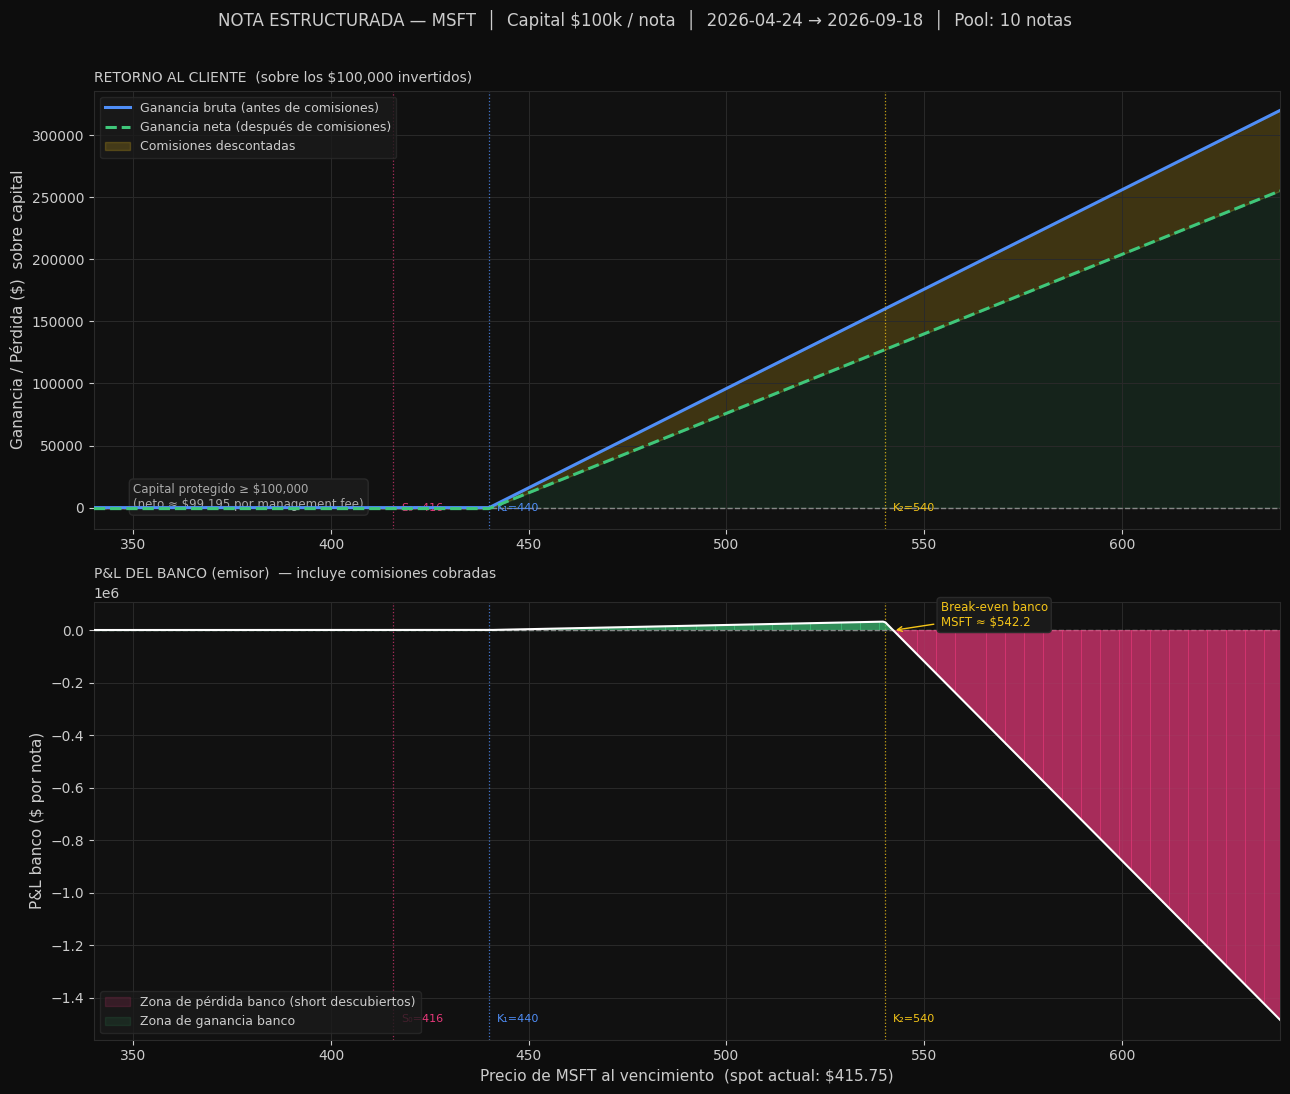

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO DE PAYOFFS — CLIENTE Y BANCO
# ─────────────────────────────────────────────────────────────────────────────

S_plot = np.linspace(340, 640, 500)

# Vectorizar las funciones sobre el grid de precios
ganancia_cli_bruta = np.array([payoff_bruto_cliente(s) - CAPITAL_NOTA for s in S_plot])
ganancia_cli_neta  = np.array([payoff_neto_cliente(s)  - CAPITAL_NOTA for s in S_plot])
pnl_banco_arr      = np.array([ganancia_banco(s) for s in S_plot])
comisiones_arr     = ganancia_cli_bruta - ganancia_cli_neta

fig, axes = plt.subplots(2, 1, figsize=(13, 11), facecolor=BG)
fig.suptitle(
    f"NOTA ESTRUCTURADA — MSFT  │  Capital $100k / nota  │  "
    f"{FECHA_INICIO_NOTA} → {FECHA_FIN_NOTA}  │  Pool: {N_NOTAS} notas",
    color=TEXT_CLR, fontsize=12, y=0.99)

ax_cli, ax_bnk = axes

for ax in axes:
    ax.set_facecolor(PANEL_BG)
    ax.axhline(0, color="#888888", lw=1.0, ls="--", zorder=2)
    # Líneas verticales de referencia
    ax.axvline(K_long,  color="#4f8ef7", lw=0.9, ls=":", alpha=0.8, zorder=2)
    ax.axvline(K_short, color="#f5c518", lw=0.9, ls=":", alpha=0.8, zorder=2)
    ax.axvline(S0,      color="#e8387a", lw=0.9, ls=":", alpha=0.7, zorder=2)
    ax.grid(True, color=GRID_CLR, lw=0.7, zorder=1)
    ax.tick_params(colors=TEXT_CLR, labelsize=10)
    for sp in ax.spines.values():
        sp.set_color(GRID_CLR)
    ax.set_xlim(340, 640)

# ─── Panel superior: CLIENTE ──────────────────────────────────────────────────
ax_cli.plot(S_plot, ganancia_cli_bruta, color="#4f8ef7", lw=2.2, zorder=4,
            label=f"Ganancia bruta (antes de comisiones)")
ax_cli.plot(S_plot, ganancia_cli_neta,  color="#3fc77a", lw=2.2, ls="--", zorder=4,
            label=f"Ganancia neta (después de comisiones)")
ax_cli.fill_between(S_plot, ganancia_cli_neta, ganancia_cli_bruta,
                    alpha=0.20, color="#f5c518", label="Comisiones descontadas")
ax_cli.fill_between(S_plot, 0, ganancia_cli_neta,
                    where=(ganancia_cli_neta >= 0), alpha=0.10, color="#3fc77a")
ax_cli.fill_between(S_plot, 0, ganancia_cli_neta,
                    where=(ganancia_cli_neta < 0),  alpha=0.10, color="#e8387a")

# Anotación: capital mínimo devuelto
ax_cli.annotate(
    f"Capital protegido ≥ ${CAPITAL_NOTA:,.0f}\n"
    f"(neto ≈ ${payoff_neto_cliente(350):,.0f} por management fee)",
    xy=(350, -400), color="#aaaaaa", fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#1a1a1a", edgecolor=GRID_CLR))

ax_cli.set_ylabel("Ganancia / Pérdida ($)  sobre capital", color=TEXT_CLR, fontsize=11)
ax_cli.set_title("RETORNO AL CLIENTE  (sobre los $100,000 invertidos)", color=TEXT_CLR,
                 fontsize=10, loc="left", pad=6)
leg = ax_cli.legend(loc="upper left", frameon=True,
                    facecolor="#1a1a1a", edgecolor=GRID_CLR, fontsize=9)
for t in leg.get_texts():
    t.set_color(TEXT_CLR)

# ─── Panel inferior: BANCO ────────────────────────────────────────────────────
colors_bar = np.where(pnl_banco_arr >= 0, "#3fc77a", "#e8387a")
bar_w = (S_plot[1] - S_plot[0]) * 1.05
ax_bnk.bar(S_plot, pnl_banco_arr, width=bar_w, color=colors_bar, alpha=0.65, zorder=3)
ax_bnk.plot(S_plot, pnl_banco_arr, color="white", lw=1.5, zorder=4)

# Zona de pérdida del banco marcada
ax_bnk.fill_between(S_plot, pnl_banco_arr, 0,
                    where=(pnl_banco_arr < 0), alpha=0.15, color="#e8387a",
                    label="Zona de pérdida banco (short descubiertos)")
ax_bnk.fill_between(S_plot, pnl_banco_arr, 0,
                    where=(pnl_banco_arr >= 0), alpha=0.10, color="#3fc77a",
                    label="Zona de ganancia banco")

# Anotación: break-even banco
be_banco_plot = K_short + (ganancia_banco(K_short) / acciones_short)
ax_bnk.annotate(
    f"Break-even banco\nMSFT ≈ ${be_banco_plot:.1f}",
    xy=(be_banco_plot, 0), xytext=(be_banco_plot + 12, ganancia_banco(K_short) * 0.5),
    color="#f5c518", fontsize=8.5, arrowprops=dict(arrowstyle="->", color="#f5c518"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1a1a", edgecolor=GRID_CLR))

ax_bnk.set_xlabel(f"Precio de MSFT al vencimiento  (spot actual: ${S0:.2f})",
                  color=TEXT_CLR, fontsize=11)
ax_bnk.set_ylabel("P&L banco ($ por nota)", color=TEXT_CLR, fontsize=11)
ax_bnk.set_title("P&L DEL BANCO (emisor)  — incluye comisiones cobradas",
                 color=TEXT_CLR, fontsize=10, loc="left", pad=6)
leg2 = ax_bnk.legend(loc="lower left", frameon=True,
                     facecolor="#1a1a1a", edgecolor=GRID_CLR, fontsize=9)
for t in leg2.get_texts():
    t.set_color(TEXT_CLR)

# ─── Etiquetas de strikes en ambos paneles ────────────────────────────────────
for ax in axes:
    ylim = ax.get_ylim()
    ytag = ylim[0] + (ylim[1] - ylim[0]) * 0.04
    ax.text(K_long  + 2, ytag, f"K₁={K_long:.0f}",  color="#4f8ef7", fontsize=8)
    ax.text(K_short + 2, ytag, f"K₂={K_short:.0f}", color="#f5c518", fontsize=8)
    ax.text(S0      + 2, ytag, f"S₀={S0:.0f}",      color="#e8387a", fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()